Read file and explore

In [31]:
import numpy as np
import rasterio
import glob
import geopandas as gpd
import pandas as pd
from pathlib import Path
import os
from rasterio.windows import from_bounds
from shapely.geometry import Point
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import json

### Exploring the data

In [33]:
#Map contain the relevant dataset for landcover classification, while the InputQuality file contains information about the quality of the input data used to generate the map. The InputQuality file can be useful for assessing the reliability of the landcover classification in different areas.

src = rasterio.open("./terrascope_download_20260625_194708/ESA_WorldCover_10m_2021_v200_N00E102_Map/ESA_WorldCover_10m_2021_v200_N00E102_Map.tif")  
src1 = rasterio.open("./terrascope_download_20260625_194708/ESA_WorldCover_10m_2021_v200_N00E102_Map/ESA_WorldCover_10m_2021_v200_N00E102_InputQuality.tif")  

In [34]:
#This shows the metadata associated with the raster data.
#It contains the datatype, width, height, crs and transform. 
#This means that the origin is: (102.0, 3.0) (top-left corner) and the pixel size is: (0.0008333, -0.0008333). 
#The negative sign in the pixel size indicates that the y-coordinate decreases as you move down the image, which is typical for raster data.
src.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': 0.0,
 'width': 36000,
 'height': 36000,
 'count': 1,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'transform': Affine(8.333333333333333e-05, 0.0, 102.0,
        0.0, -8.333333333333333e-05, 3.0)}

In [35]:
#Shows the coordinate bounds for the raster data. 
src1.bounds

BoundingBox(left=102.0, bottom=0.0, right=105.0, top=3.0)

In [36]:
#Other info about the data
print(src1.descriptions)
print(src1.tags())

(None, None, None)
{'algorithm_version': 'V2.0.0', 'copyright': 'ESA WorldCover project 2021 / Contains modified Copernicus Sentinel data (2021) processed by ESA WorldCover consortium', 'creation_time': '2022-08-03 16:43:52.733279', 'description': 'Band 1: Number of Sentinel-1 GAMMA0 observations used in the classification workflow,\n            Band 2: Number of Sentinel-2 L2A observations used in the classification workflow,\n            Band 3: Percentage (0-100) of invalid S2 observations discarded in the classification workflow (after cloud and cloud shadow filtering).\n\n            \nCombining Band 2 and Band 3 yields the total absolute number of valid Sentinel-2 L2A observations used in the classification workflow.', 'license': 'CC-BY 4.0 - https://creativecommons.org/licenses/by/4.0/', 'OVR_RESAMPLING_ALG': 'NEAREST', 'product_crs': 'EPSG:4326', 'product_grid': '3x3 degree tiling grid', 'product_tile': 'N00E102', 'product_type': 'Input Quality Layer', 'product_version': 'V2.0.

In [37]:
#Reading a sample of the data at a particular cell. 
lon = 102.35
lat = 2.68
row, col = src.index(102.35, 2.68)
value = src.read(1)[row, col]
value

np.uint8(30)

ERA5_Land data resolution is 0.1 degrees, which is approximately 11 km at the equator. 
The WorldCover data has a much higher resolution of 10 meters.
To enhance the PV data with this landcover raster data:
- For each cell, create a window of interest. This window should be the same resolution as the ERA5_Land.
- Read the raster data in the window. 
- Compute fraction of landcover types within the window. 

### Preparing datasets
Preprocessing steps to prep the data.

In [2]:
#Getting all the files which contain the Map.
directory = "./terrascope_download_20260625_194708"
file_paths = glob.glob(f"{directory}/*/*_Map.tif", recursive=True)

#Creating a dictionary of bounds:file_path
FILE_BOUNDS = {}
for file_path in file_paths:
    with rasterio.open(file_path) as src:
        FILE_BOUNDS[src.bounds] = file_path

print(FILE_BOUNDS)

{BoundingBox(left=99.0, bottom=0.0, right=102.0, top=3.0): './terrascope_download_20260625_194708\\ESA_WorldCover_10m_2021_v200_N00E099_Map\\ESA_WorldCover_10m_2021_v200_N00E099_Map.tif', BoundingBox(left=102.0, bottom=0.0, right=105.0, top=3.0): './terrascope_download_20260625_194708\\ESA_WorldCover_10m_2021_v200_N00E102_Map\\ESA_WorldCover_10m_2021_v200_N00E102_Map.tif', BoundingBox(left=108.0, bottom=0.0, right=111.0, top=3.0): './terrascope_download_20260625_194708\\ESA_WorldCover_10m_2021_v200_N00E108_Map\\ESA_WorldCover_10m_2021_v200_N00E108_Map.tif', BoundingBox(left=111.0, bottom=0.0, right=114.0, top=3.0): './terrascope_download_20260625_194708\\ESA_WorldCover_10m_2021_v200_N00E111_Map\\ESA_WorldCover_10m_2021_v200_N00E111_Map.tif', BoundingBox(left=114.0, bottom=0.0, right=117.0, top=3.0): './terrascope_download_20260625_194708\\ESA_WorldCover_10m_2021_v200_N00E114_Map\\ESA_WorldCover_10m_2021_v200_N00E114_Map.tif', BoundingBox(left=117.0, bottom=0.0, right=120.0, top=3.0): '

In [3]:
#Open a raster dataset for each file path and store them in a dictionary. 
#These dataset remains opened until closed. 
DATASETS = {
    fp: rasterio.open(fp)
    for fp in file_paths
}
print(DATASETS)

{'./terrascope_download_20260625_194708\\ESA_WorldCover_10m_2021_v200_N00E099_Map\\ESA_WorldCover_10m_2021_v200_N00E099_Map.tif': <open DatasetReader name='./terrascope_download_20260625_194708\ESA_WorldCover_10m_2021_v200_N00E099_Map\ESA_WorldCover_10m_2021_v200_N00E099_Map.tif' mode='r'>, './terrascope_download_20260625_194708\\ESA_WorldCover_10m_2021_v200_N00E102_Map\\ESA_WorldCover_10m_2021_v200_N00E102_Map.tif': <open DatasetReader name='./terrascope_download_20260625_194708\ESA_WorldCover_10m_2021_v200_N00E102_Map\ESA_WorldCover_10m_2021_v200_N00E102_Map.tif' mode='r'>, './terrascope_download_20260625_194708\\ESA_WorldCover_10m_2021_v200_N00E108_Map\\ESA_WorldCover_10m_2021_v200_N00E108_Map.tif': <open DatasetReader name='./terrascope_download_20260625_194708\ESA_WorldCover_10m_2021_v200_N00E108_Map\ESA_WorldCover_10m_2021_v200_N00E108_Map.tif' mode='r'>, './terrascope_download_20260625_194708\\ESA_WorldCover_10m_2021_v200_N00E111_Map\\ESA_WorldCover_10m_2021_v200_N00E111_Map.tif

In [4]:
#Reading the pv data file
BASE_DIR = Path(os.getcwd()).resolve().parent / "data"
ds = pd.read_parquet(BASE_DIR / "enriched_malaysia_pv_monthly.parquet")

display(ds.head())

,y,x,time,lat,lon,pv,state_id,district_id
72504,0.9,110.5,2023-01-31,0.9,110.5,105.310156,14,123
72505,0.9,110.5,2023-02-28,0.9,110.5,95.694441,14,123
72506,0.9,110.5,2023-03-31,0.9,110.5,101.319780,14,123
72507,0.9,110.5,2023-04-30,0.9,110.5,120.534080,14,123
72508,0.9,110.5,2023-05-31,0.9,110.5,122.068659,14,123


In [5]:
#Get the unique lat/long so that we can get the raster data for each unique location once to save time and memory and avoid unnecessary work. 
unique_locations = ds[["lat", "lon"]].drop_duplicates()
display(unique_locations)

,lat,lon
72504,0.9,110.5
72540,0.9,110.6
72576,0.9,110.7
72612,0.9,110.8
80028,1.0,110.3
...,...,...
553428,7.2,117.1
553464,7.2,117.2
560988,7.3,117.0
561024,7.3,117.1


### Raster functions
These functions is to allow us to get the relevant data for each cell in the PV dataset. 

In [6]:
#Calculate which file to read based on the coodinates covered by the tif
def check_file_for_coordinates(row, file_bounds):
    for bounds, file_path in file_bounds.items():
        if bounds.left <= row["lon"] <= bounds.right and bounds.bottom <= row["lat"] <= bounds.top:
            return file_path
    return None

In [7]:
#Create window around center coordinates of PV cell. This is following atlite's grid size
def create_window(file_path, row, size=0.1):
    if file_path is None:
        return None
    
    #Reading the raster file according to the file path in the row
    src = DATASETS[file_path]
    
    half_size = size / 2
    left = row["lon"] - half_size
    right = row["lon"] + half_size
    bottom = row["lat"] - half_size
    top = row["lat"] + half_size
    #print(f"Creating window for lon: {lon}, lat: {lat}, size: {size}. left: {left}, right: {right}, bottom: {bottom}, top: {top}")

    window = from_bounds(
        left,
        bottom,
        right,
        top,
        transform=src.transform
    )
    return window

In [8]:
def read_window(window, file_path):
    if file_path is None:
        return None
    else:
        src = DATASETS[file_path]
        return src.read(1, window=window)

# Close datasets after using
def close_datasets():
    for src in DATASETS.values():
        src.close()

In [9]:
WORLDCOVER_CLASSES = [10,20,30,40,50,60,70,80,90,95,100]

def calculate_landcover_percentage(raster_data):

    if raster_data is None:
        return None
    
    counts = np.bincount(raster_data.ravel(), minlength=101)

    total = counts.sum()

    return {
        cls: round(counts[cls] / total * 100, 2)
        for cls in WORLDCOVER_CLASSES
    }

In [12]:
def get_landcover(row, file_bounds):

    #Check which file to read based on coordinates
    file_path = check_file_for_coordinates(row, file_bounds)
    
    #Create window around center coordinates of PV cell
    window = create_window(file_path, row, size=0.1)

    #Read the raster data for the window
    raster_data = read_window(window, file_path)

    #Calculate the landcover percentage for the raster data
    landcover_percentage = calculate_landcover_percentage(raster_data)

    return landcover_percentage
    

### Enhancing the datasets.
We will use the functions above to add raster information into the pv data.


In [13]:
#For debugging, let's assign intermediate values to the columns.
enhanced_pv_cells = unique_locations.copy()

enhanced_pv_cells["file_path"] = enhanced_pv_cells.apply(lambda row: check_file_for_coordinates(row, FILE_BOUNDS), axis=1)
enhanced_pv_cells["window"] = enhanced_pv_cells.apply(lambda row: create_window(row["file_path"], row, size=0.1), axis=1)
enhanced_pv_cells["raster_data"] = enhanced_pv_cells.apply(lambda row: read_window(row["window"], row["file_path"]), axis=1)
enhanced_pv_cells["landcover_percentage"] = enhanced_pv_cells.apply(lambda row: calculate_landcover_percentage(row["raster_data"]), axis=1)


In [14]:

#An easy way to ensure if all cells have some landcover raster data is to ensure no nulls in file_path.
display(enhanced_pv_cells.loc[enhanced_pv_cells["landcover_percentage"].isnull()] )

for fp in enhanced_pv_cells["file_path"].unique():
    print(fp)

,lat,lon,file_path,window,raster_data,landcover_percentage


./terrascope_download_20260625_194708\ESA_WorldCover_10m_2021_v200_N00E108_Map\ESA_WorldCover_10m_2021_v200_N00E108_Map.tif
./terrascope_download_20260625_194708\ESA_WorldCover_10m_2021_v200_N00E111_Map\ESA_WorldCover_10m_2021_v200_N00E111_Map.tif
./terrascope_download_20260625_194708\ESA_WorldCover_10m_2021_v200_N00E102_Map\ESA_WorldCover_10m_2021_v200_N00E102_Map.tif
./terrascope_download_20260625_194708\ESA_WorldCover_10m_2021_v200_N00E114_Map\ESA_WorldCover_10m_2021_v200_N00E114_Map.tif
./terrascope_download_20260625_194708\ESA_WorldCover_10m_2021_v200_N00E099_Map\ESA_WorldCover_10m_2021_v200_N00E099_Map.tif
./terrascope_download_20260625_194708\ESA_WorldCover_10m_2021_v200_N03E099_Map\ESA_WorldCover_10m_2021_v200_N03E099_Map.tif
./terrascope_download_20260625_194708\ESA_WorldCover_10m_2021_v200_N03E102_Map\ESA_WorldCover_10m_2021_v200_N03E102_Map.tif
./terrascope_download_20260625_194708\ESA_WorldCover_10m_2021_v200_N03E111_Map\ESA_WorldCover_10m_2021_v200_N03E111_Map.tif
./terras

In [15]:
#Since we are going to perform geographical functions on the dataset, let's convert the pandas dataset into a geopandas dataset using the coordinates.
geodf_enhanced_pv_dataset = gpd.GeoDataFrame(
    enhanced_pv_cells,
    geometry=gpd.points_from_xy(enhanced_pv_cells.lon, enhanced_pv_cells.lat),
    crs="EPSG:4326"
)

In [16]:
#Visualizing the columns
display(geodf_enhanced_pv_dataset)

,lat,lon,file_path,window,raster_data,landcover_percentage,geometry
72504,0.9,110.5,./terrascope_download_20260625_194708\ESA_Worl...,"Window(col_off=np.float64(29400.0), row_off=np...","[[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, ...","{10: 97.68, 20: 0.0, 30: 1.84, 40: 0.07, 50: 0...",POINT (110.5 0.9)
72540,0.9,110.6,./terrascope_download_20260625_194708\ESA_Worl...,"Window(col_off=np.float64(30600.0), row_off=np...","[[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, ...","{10: 96.09, 20: 0.0, 30: 2.86, 40: 0.62, 50: 0...",POINT (110.6 0.9)
72576,0.9,110.7,./terrascope_download_20260625_194708\ESA_Worl...,"Window(col_off=np.float64(31800.0), row_off=np...","[[10, 10, 10, 10, 10, 30, 10, 10, 10, 10, 10, ...","{10: 98.22, 20: 0.0, 30: 1.55, 40: 0.02, 50: 0...",POINT (110.7 0.9)
72612,0.9,110.8,./terrascope_download_20260625_194708\ESA_Worl...,"Window(col_off=np.float64(33000.0), row_off=np...","[[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, ...","{10: 98.14, 20: 0.02, 30: 1.74, 40: 0.05, 50: ...",POINT (110.8 0.9)
80028,1.0,110.3,./terrascope_download_20260625_194708\ESA_Worl...,"Window(col_off=np.float64(27000.0), row_off=np...","[[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, ...","{10: 97.35, 20: 0.0, 30: 2.07, 40: 0.04, 50: 0...",POINT (110.3 1)
...,...,...,...,...,...,...,...
553428,7.2,117.1,./terrascope_download_20260625_194708\ESA_Worl...,"Window(col_off=np.float64(600.0), row_off=np.f...","[[80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, ...","{10: 75.57, 20: 0.0, 30: 2.48, 40: 0.01, 50: 0...",POINT (117.1 7.2)
553464,7.2,117.2,./terrascope_download_20260625_194708\ESA_Worl...,"Window(col_off=np.float64(1800.0), row_off=np....","[[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, ...","{10: 44.11, 20: 0.0, 30: 0.44, 40: 0.0, 50: 0....",POINT (117.2 7.2)
560988,7.3,117.0,./terrascope_download_20260625_194708\ESA_Worl...,"Window(col_off=np.float64(35400.0), row_off=np...","[[80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, ...","{10: 10.25, 20: 0.02, 30: 24.9, 40: 0.04, 50: ...",POINT (117 7.3)
561024,7.3,117.1,./terrascope_download_20260625_194708\ESA_Worl...,"Window(col_off=np.float64(600.0), row_off=np.f...","[[80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, ...","{10: 53.08, 20: 0.0, 30: 1.32, 40: 0.01, 50: 0...",POINT (117.1 7.3)


### Sanity check
We can visualize the window and the raster that is read for a given coordinates to validate if the landcover percentage make sense. 

In [17]:
#Given a user input of a certain longitude and latitude, we will return the closest cell (determined in meters)
def find_closest_cell(df, longitude, latitude):
    df_projected = df.to_crs("EPSG:3857")

    #Convert the CRS to a projected coordinates system using coordinates in meters. 
    target = (
        gpd.GeoSeries([Point(longitude, latitude)], crs="EPSG:4326")
        .to_crs("EPSG:3857")
        .iloc[0]
    )

    closest_idx = df_projected.distance(target).idxmin()
    closest_row = df.loc[[closest_idx]]
    return closest_row

In [18]:
test_result = find_closest_cell(geodf_enhanced_pv_dataset, 101.55, 3.17).iloc[0]

print(f'Latitude: {test_result["lat"]}')
print(f'Longitude: {test_result["lon"]}')
print(f'Landcover percentage: {test_result["landcover_percentage"]}')

# {10: 47.71, 20: 0.0, 30: 3.64, 40: 0.04, 50: 46.74, 60: 1.3, 70: 0.0, 80: 0.57, 90: 0.0, 95: 0.0, 100: 0.0}
#print(find_closest_cell(geodf_enhanced_pv_dataset, 101.55, 3.17).to_string()

Latitude: 3.2
Longitude: 101.6
Landcover percentage: {10: np.float64(47.71), 20: np.float64(0.0), 30: np.float64(3.64), 40: np.float64(0.04), 50: np.float64(46.74), 60: np.float64(1.3), 70: np.float64(0.0), 80: np.float64(0.57), 90: np.float64(0.0), 95: np.float64(0.0), 100: np.float64(0.0)}


In [19]:
#Visualization function

def visualize_raster_window(df, latitude, longitude):
    result = find_closest_cell(df, latitude, longitude).iloc[0]

    print(f'Latitude: {result["lat"]}')
    print(f'Longitude: {result["lon"]}')
    print(f'Landcover percentage: {result["landcover_percentage"]}')

    # WorldCover classes and labels
    CLASS_LABELS = {
        10: "Tree cover",
        20: "Shrubland",
        30: "Grassland",
        40: "Cropland",
        50: "Built-up",
        60: "Bare / sparse vegetation",
        70: "Snow & ice",
        80: "Permanent water",
        90: "Herbaceous wetland",
        95: "Mangroves",
        100: "Moss & lichen",
    }

    # One colour for each class
    colors = [
        "#006400",  # 10 Tree
        "#ffbb22",  # 20 Shrubland
        "#ffff4c",  # 30 Grassland
        "#f096ff",  # 40 Cropland
        "#fa0000",  # 50 Built-up
        "#b4b4b4",  # 60 Bare
        "#f0f0f0",  # 70 Snow
        "#0064c8",  # 80 Water
        "#0096a0",  # 90 Wetland
        "#00cf75",  # 95 Mangroves
        "#fae6a0",  # 100 Moss
    ]

    cmap = ListedColormap(colors)

    # Class boundaries
    bounds = [10,20,30,40,50,60,70,80,90,95,100,101]
    #Change the tick positions to be in the middle of the boundaries. 
    tick_positions = [(bounds[i] + bounds[i+1]) / 2 for i in range(len(bounds)-1)]
    norm = BoundaryNorm(bounds, cmap.N)

    window = result["window"]
    file_path = result["file_path"]
    src_test = DATASETS[file_path]
    lon = result["lon"]
    lat = result["lat"]
    data = src_test.read(1, window=window)
    left, bottom, right, top = rasterio.windows.bounds(window, src_test.transform)

    fig, ax = plt.subplots(figsize=(8,8))
    img = ax.imshow(
        data,
        cmap=cmap,
        norm=norm,
        extent=(left, right, bottom, top),
        origin="upper"
    )

    ax.scatter(lon, lat, color="black", s=50, marker="x")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    # Create colorbar
    cbar = plt.colorbar(img, ax=ax)

    classes = list(CLASS_LABELS.keys())
    cbar.set_ticks(tick_positions)
    cbar.set_ticklabels(
        [f"{c} - {CLASS_LABELS[c]}" for c in classes]
    )

    cbar.set_label("ESA WorldCover Class")

    plt.show()



Latitude: 3.2
Longitude: 101.6
Landcover percentage: {10: np.float64(47.71), 20: np.float64(0.0), 30: np.float64(3.64), 40: np.float64(0.04), 50: np.float64(46.74), 60: np.float64(1.3), 70: np.float64(0.0), 80: np.float64(0.57), 90: np.float64(0.0), 95: np.float64(0.0), 100: np.float64(0.0)}


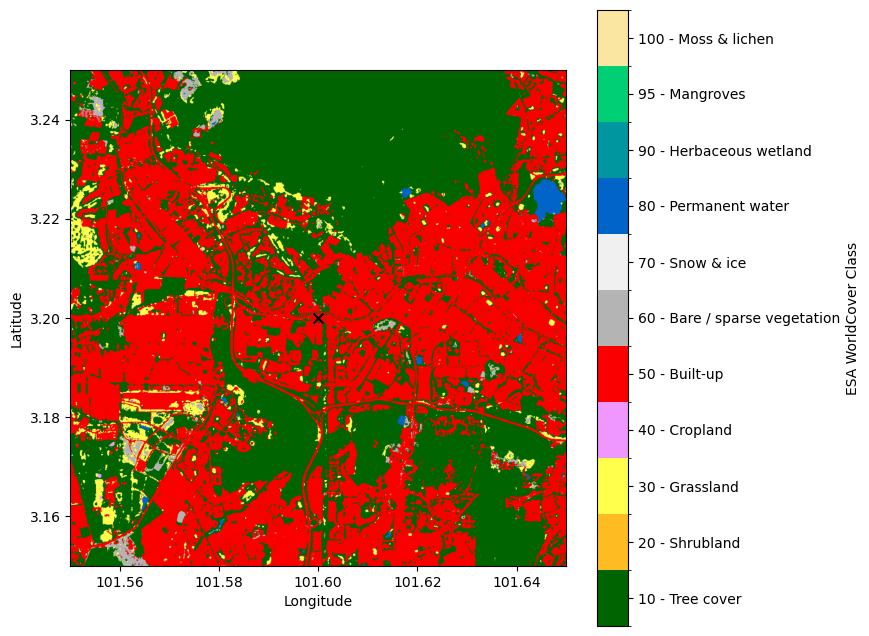

In [20]:
#Testing a urban area. Should have more built up.
visualize_raster_window(geodf_enhanced_pv_dataset,101.55, 3.17)
# {10: 47.71, 20: 0.0, 30: 3.64, 40: 0.04, 50: 46.74, 60: 1.3, 70: 0.0, 80: 0.57, 90: 0.0, 95: 0.0, 100: 0.0}
# The window is formed by the size of the grid in era5-land (0.1 degree grid sizze)
# This test looks reasonable

Latitude: 3.2
Longitude: 101.7
Landcover percentage: {10: np.float64(30.16), 20: np.float64(0.0), 30: np.float64(2.17), 40: np.float64(0.13), 50: np.float64(65.16), 60: np.float64(0.76), 70: np.float64(0.0), 80: np.float64(1.63), 90: np.float64(0.0), 95: np.float64(0.0), 100: np.float64(0.0)}


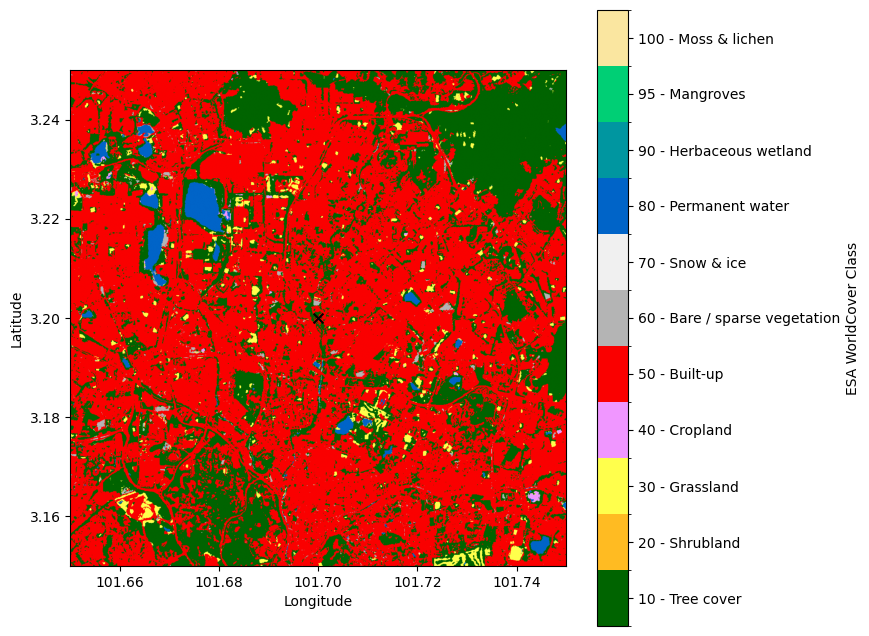

In [21]:
#Testing a urban area. Should have more built up.
visualize_raster_window(geodf_enhanced_pv_dataset, 101.69, 3.19)
# {10: 30.16, 20: 0.0, 30: 2.17, 40: 0.13, 50: 65.16, 60: 0.76, 70: 0.0, 80: 1.63, 90: 0.0, 95: 0.0, 100: 0.0}
# This test looks reasonable

Latitude: 3.5
Longitude: 101.1
Landcover percentage: {10: np.float64(10.77), 20: np.float64(0.0), 30: np.float64(3.66), 40: np.float64(33.49), 50: np.float64(4.28), 60: np.float64(0.19), 70: np.float64(0.0), 80: np.float64(47.12), 90: np.float64(0.16), 95: np.float64(0.33), 100: np.float64(0.0)}


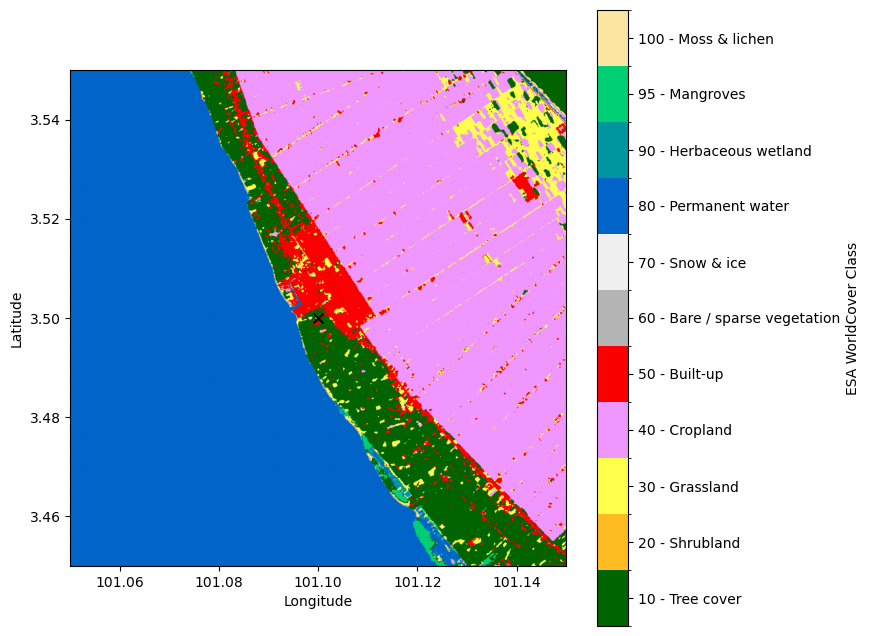

In [22]:
#Testing a coastal cropland area. Should have more water and cropland percentage. 
visualize_raster_window(geodf_enhanced_pv_dataset,  101.10, 3.51)

# {10: 10.77, 20: 0.0, 30: 3.66, 40: 33.49, 50: 4.28, 60: 0.19, 70: 0.0, 80: 47.12, 90: 0.16, 95: 0.33, 100: 0.0}
# This test looks reasonable

Latitude: 3.8
Longitude: 102.1
Landcover percentage: {10: np.float64(99.96), 20: np.float64(0.0), 30: np.float64(0.04), 40: np.float64(0.0), 50: np.float64(0.0), 60: np.float64(0.0), 70: np.float64(0.0), 80: np.float64(0.0), 90: np.float64(0.0), 95: np.float64(0.0), 100: np.float64(0.0)}


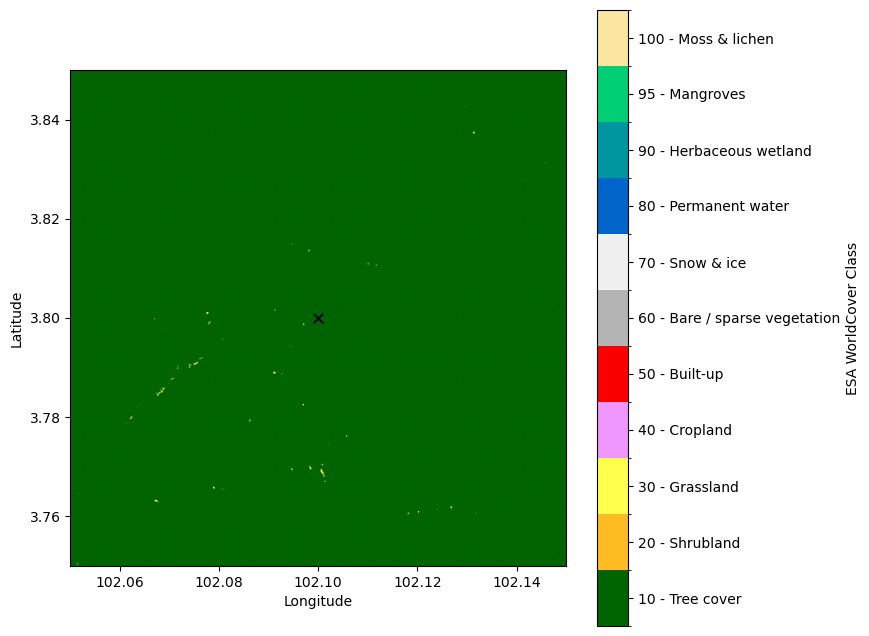

In [23]:
#Testing a forested area. Should have mostly tree cover.
visualize_raster_window(geodf_enhanced_pv_dataset,  102.097, 3.82)
#10: 99.96, 20: 0.0, 30: 0.04, 40: 0.0, 50: 0.0, 60: 0.0, 70: 0.0, 80: 0.0, 90: 0.0, 95: 0.0, 100: 0.0}  
# This test looks reasonable

### Writing to file
Since we are satisfied with the results, let's write the landcover data into a parquet file

In [27]:
final_dataset = geodf_enhanced_pv_dataset.loc[:,["lat","lon", "landcover_percentage"]]

In [28]:
display(final_dataset)

,lat,lon,landcover_percentage
72504,0.9,110.5,"{10: 97.68, 20: 0.0, 30: 1.84, 40: 0.07, 50: 0..."
72540,0.9,110.6,"{10: 96.09, 20: 0.0, 30: 2.86, 40: 0.62, 50: 0..."
72576,0.9,110.7,"{10: 98.22, 20: 0.0, 30: 1.55, 40: 0.02, 50: 0..."
72612,0.9,110.8,"{10: 98.14, 20: 0.02, 30: 1.74, 40: 0.05, 50: ..."
80028,1.0,110.3,"{10: 97.35, 20: 0.0, 30: 2.07, 40: 0.04, 50: 0..."
...,...,...,...
553428,7.2,117.1,"{10: 75.57, 20: 0.0, 30: 2.48, 40: 0.01, 50: 0..."
553464,7.2,117.2,"{10: 44.11, 20: 0.0, 30: 0.44, 40: 0.0, 50: 0...."
560988,7.3,117.0,"{10: 10.25, 20: 0.02, 30: 24.9, 40: 0.04, 50: ..."
561024,7.3,117.1,"{10: 53.08, 20: 0.0, 30: 1.32, 40: 0.01, 50: 0..."


In [ ]:
#Since the landcover_percentage is a dictionary, we cannot use to_parquet directly since there will be a conversion error.
#Convert the dicts to str first before writing
final_dataset["landcover_percentage"] = final_dataset["landcover_percentage"].apply(json.dumps)
final_dataset.to_parquet(BASE_DIR/"landcover_percentage.parquet")

#To read it back:
# df_read = pd.read_parquet("output.parquet")
# df_read["col"] = df_read["col"].apply(json.loads)

In [24]:
close_datasets()